# 03 · Model comparison and probability diagnostics

**A completed experiment you can open and inspect.** This notebook connects the verified feature store to nested temporal model comparison. It includes saved outputs, direct metric checks, calibration, uncertainty, model choices, and feature interpretation.

The current run compares **logistic regression, histogram boosting, XGBoost and LightGBM**, with seed and ranking baselines. Separate and pooled fits use identical common-feature candidates. Every decision uses seasons earlier than the season being predicted.

**Evidence status:** retrospective development research. These years have been explored before. The previously evaluated 2022–2025 benchmark is already consumed; this notebook does not claim an untouched test score or a new Kaggle result.

In [1]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from march_mania.modeling import candidates, columns_for
from march_mania.notebook_support import review_source, table, style
from march_mania.runtime import EventLog

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
STARTED = time.monotonic()
LOG = EventLog(ROOT / "outputs/validation/model_notebook.jsonl")
LOG.emit("notebook_started", notebook="03_model_comparison_and_diagnostics")
style()
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "figure.facecolor": "white"})
RESULTS, SUMMARY, SOURCE = review_source(ROOT, "model_comparison", 124)
assert RESULTS is not None, "No completed model comparison evidence is available"
CONFIG = json.loads((ROOT / "configs/model_comparison.json").read_text())
display(Markdown(f"**Evidence source:** {SOURCE}. **Run:** `{SUMMARY['fingerprint']}`."))

{"elapsed_seconds": 0.0, "event": "notebook_started", "memory_status": "available", "notebook": "03_model_comparison_and_diagnostics", "rss_mb": 255.9, "timestamp": "2026-09-07T04:49:47.140100+00:00"}


**Evidence source:** recorded Git evidence (checksums verified). **Run:** `7a0a997b0531091bc6cdf4c962d96791a73b99259d4af9a4cae1a32a4fa13526`.

## 1. Where this fits

Read **00 → 01 → 02 → 03** to follow the analysis. Each notebook loads persisted evidence, so opening 03 does not depend on having executed earlier notebook cells.

- **00:** official download, checksums, raw-data inventory and basketball exploration.
- **01:** pre-tournament cutoff and chronological splits.
- **02:** 124 candidate features and measured family ablations.
- **03:** model selection, probability calibration and ensembles using that feature store.
- **04:** historical benchmark and submission. A new final recipe still requires reconciliation with the current model evidence.

The canonical Python engine is `src/march_mania/modeling.py`. The executed notebook is the analytical narrative; functions and tests provide reusable, independently checkable implementation.

In [2]:
table(pd.DataFrame([
    {"measure": "Candidate model fits", "value": SUMMARY["fit_tasks"]},
    {"measure": "Outer selection contexts", "value": SUMMARY["selection_tasks"]},
    {"measure": "Unique outer tournament games", "value": SUMMARY["physical_validation_games"]},
    {"measure": "Saved prediction rows", "value": SUMMARY["prediction_rows"]},
    {"measure": "Measured candidate fit seconds", "value": SUMMARY["training_seconds"]},
    {"measure": "Run elapsed seconds", "value": SUMMARY["elapsed_seconds"]},
]))
assert SUMMARY["feature_fingerprint"] == json.loads(
    (ROOT / "reports/feature_store/run.json").read_text())["summary"]["fingerprint"]
LOG.emit("feature_lineage_verified", feature_fingerprint=SUMMARY["feature_fingerprint"])

measure,value
Candidate model fits,497.000000
Outer selection contexts,20.000000
Unique outer tournament games,649.000000
Saved prediction rows,14946.000000
Measured candidate fit seconds,45.927000
Run elapsed seconds,63.384000


{"elapsed_seconds": 0.015, "event": "feature_lineage_verified", "feature_fingerprint": "188b49c593302bb8dd11032a0a3d0f74eedaf2fe28bf6ba1ebe5fb6e39699724", "memory_status": "available", "rss_mb": 256.9, "timestamp": "2026-09-07T04:49:47.155218+00:00"}


## 2. A bounded model search

Small historical tournament samples reward regularization. The search compares predefined basketball feature groups and a compact set of penalties/tree sizes. It does not tune hundreds of parameters or select training duration on outer-season outcomes.

Logistic regression uses fold-fitted median imputation and standardization. All boosting engines use **120 trees/iterations**, a learning rate of **0.04**, and explicit regularization. Training is sequential with two CPU threads. Mirrored team pairs are created **after** selecting the training seasons.

The separate and pooled comparisons have the same **101 common features** available. The men's `rank_logistic` stream separately tests Massey ranking features; it is excluded from the common-feature ensemble.

In [3]:
search_rows = []
for route in ["M", "W", "pooled_common"]:
    for candidate in candidates(route):
        search_rows.append({"route": route, "family": candidate.family,
                            "candidate": candidate.name, "block": candidate.block,
                            "features": len(columns_for(candidate))})
search = pd.DataFrame(search_rows)
table(search.groupby(["route", "family"]).agg(
    candidate_settings=("candidate", "nunique"), feature_groups=("block", "nunique"),
    smallest_matrix=("features", "min"), largest_matrix=("features", "max")
).reset_index())

route,family,candidate_settings,feature_groups,smallest_matrix,largest_matrix
M,hist,4,2,6,101
M,lightgbm,4,2,6,101
M,logistic,10,5,6,101
M,rank_logistic,2,1,19,19
M,seed,1,1,1,1
M,xgboost,4,2,6,101
W,hist,4,2,6,101
W,lightgbm,4,2,6,101
W,logistic,10,5,6,101
W,seed,1,1,1,1


## 3. Temporal selection, calibration and blending

For an outer season, every candidate is evaluated on earlier expanding-window folds. Mean season Brier selects one candidate per family. Calibration compares identity with temperature scaling using **forward-only inner calibration folds**, then fits the selected method on earlier OOF probabilities. Temperature scaling preserves team-swap symmetry.

The ensemble fits nonnegative weights summing to one, with regularization toward equal weights, on selected **raw** inner OOF streams. Calibration-adjusted training predictions are not substituted for honest base-model OOF predictions.

For the earliest outer season (2016), only 2014 and 2015 are available as inner validation years; calibration selection therefore has only one forward validation year. That is a real limitation, not extra evidence. All reported outer forecasts are scored only after these decisions.

In [4]:
selection = pd.read_csv(RESULTS / "selection.csv")
assert (selection.history_last_season < selection.Season).all()
assert (selection.history_seasons >= 2).all()
assert set(selection.Season) == set(CONFIG["validation_seasons"])
assert selection.temperature.between(0.5, 2.0).all()
table(selection.query("Season == 2021")[["Gender", "route", "family", "candidate",
                                        "calibration", "temperature", "history_last_season"]])
LOG.emit("temporal_decisions_verified", selected_family_folds=len(selection))

Gender,route,family,candidate,calibration,temperature,history_last_season
M,M,hist,hist_strength_2,identity,1.000000,2019
M,M,lightgbm,lightgbm_strength_3,identity,1.000000,2019
M,M,logistic,logistic_strength_1,identity,1.000000,2019
M,M,rank_logistic,rank_logistic_0,identity,1.000000,2019
M,M,seed,seed,temperature,0.772708,2019
M,M,xgboost,xgboost_strength_3,identity,1.000000,2019
W,W,hist,hist_strength_2,identity,1.000000,2019
W,W,lightgbm,lightgbm_strength_2,identity,1.000000,2019
W,W,logistic,logistic_dynamic_1,identity,1.000000,2019
W,W,seed,seed,identity,1.000000,2019


{"elapsed_seconds": 0.05, "event": "temporal_decisions_verified", "memory_status": "available", "rss_mb": 258.8, "selected_family_folds": 105, "timestamp": "2026-09-07T04:49:47.189475+00:00"}


## 4. Recompute the metric from saved predictions

[Kaggle's official competition metric](https://www.kaggle.com/competitions/march-machine-learning-mania-2026) is **Brier score**, the mean squared error of the predicted win probability. Lower is better. We also report log loss, ROC AUC, average precision, precision/recall/F1 at 0.5, and calibration error.

The leaderboard contains both **game-weighted Brier** and **mean season Brier**. Model selection weights seasons equally so a season with extra play-in games does not receive more influence. The positive class is the lower TeamID winning; no tournament game is counted twice within a prediction stream.

In [5]:
prediction_file = RESULTS / "predictions.parquet"
predictions = (pd.read_parquet(prediction_file) if prediction_file.exists()
               else pd.read_csv(RESULTS / "predictions.csv"))
leaderboard = pd.read_csv(RESULTS / "leaderboard.csv")
metrics = pd.read_csv(RESULTS / "metrics_by_season.csv")
KEYS = ["Gender", "Season", "block", "model", "ID"]
assert not predictions.duplicated(KEYS).any()
assert predictions.p.between(0, 1).all() and np.isfinite(predictions.p).all()
assert set(predictions.Season) == set(CONFIG["validation_seasons"])
scored = predictions.assign(loss=(predictions.y - predictions.p) ** 2)
computed = scored.groupby(["Gender", "block", "model"]).loss.mean().rename("computed_brier")
check = leaderboard.merge(computed, on=["Gender", "block", "model"], validate="one_to_one")
assert np.allclose(check.brier, check.computed_brier, atol=1e-12, rtol=0)
season_check = scored.groupby(["Gender", "Season", "block", "model"]).loss.mean()
macro = season_check.groupby(["Gender", "block", "model"]).mean().rename("computed_macro")
check = check.merge(macro, on=["Gender", "block", "model"], validate="one_to_one")
assert np.allclose(check.macro_season_brier, check.computed_macro, atol=1e-12, rtol=0)
LOG.emit("metrics_recomputed", prediction_rows=len(predictions), streams=len(leaderboard))
table(leaderboard.sort_values(["Gender", "macro_season_brier"]).groupby("Gender").head(6)
      [["Gender", "block", "model", "macro_season_brier", "brier", "log_loss",
        "roc_auc", "average_precision", "games"]])

{"elapsed_seconds": 0.087, "event": "metrics_recomputed", "memory_status": "available", "prediction_rows": 14946, "rss_mb": 263.0, "streams": 46, "timestamp": "2026-09-07T04:49:47.226571+00:00"}


Gender,block,model,macro_season_brier,brier,log_loss,roc_auc,average_precision,games
M,M,rank_logistic_calibrated,0.188476,0.188409,0.554587,0.792532,0.770554,334
M,M,rank_logistic_raw,0.188476,0.188409,0.554587,0.792532,0.770554,334
M,pooled_common,blend,0.190919,0.190840,0.557529,0.786580,0.768873,334
M,M,logistic_raw,0.191452,0.191358,0.558046,0.781421,0.764935,334
M,pooled_common,xgboost_calibrated,0.191505,0.191436,0.559290,0.780087,0.756500,334
M,pooled_common,xgboost_raw,0.191505,0.191436,0.559290,0.780087,0.756500,334
W,W,logistic_calibrated,0.143867,0.143867,0.429935,0.878941,0.881182,315
W,W,logistic_raw,0.143867,0.143867,0.429935,0.878941,0.881182,315
W,pooled_common,logistic_raw,0.145906,0.145906,0.436233,0.874466,0.876034,315
W,pooled_common,blend,0.146494,0.146494,0.443318,0.873095,0.872331,315


## 5. Which models performed best?

The plots compare identical outer seasons. Both raw and calibrated results remain in the tables so an unsuccessful calibration step is visible. The minimum on this development scoreboard is a candidate for further work, not an independently confirmed final winner.

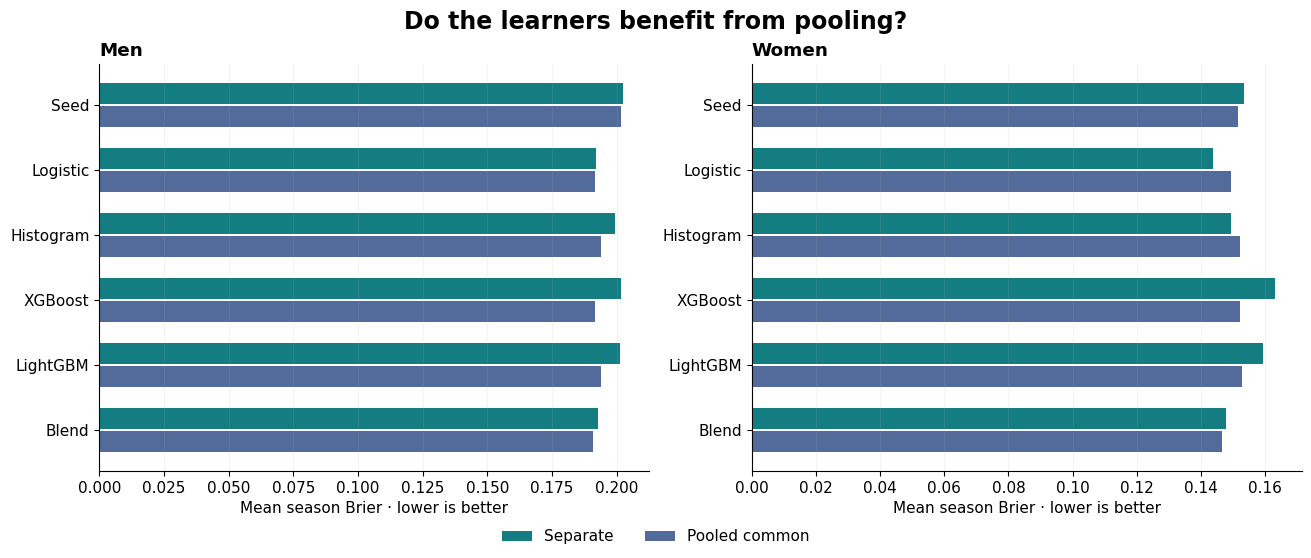

**Men:** lowest observed mean season Brier **0.188476**, `rank_logistic_calibrated` / `M`.

**Women:** lowest observed mean season Brier **0.143867**, `logistic_calibrated` / `W`.

In [6]:
MODELS = ["seed_calibrated", "logistic_calibrated", "hist_calibrated",
          "xgboost_calibrated", "lightgbm_calibrated", "blend"]
LABELS = ["Seed", "Logistic", "Histogram", "XGBoost", "LightGBM", "Blend"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
for ax, gender, title in zip(axes, ["M", "W"], ["Men", "Women"]):
    for offset, route, color, label in [(-0.18, gender, "#147d82", "Separate"),
                                        (0.18, "pooled_common", "#526b9a", "Pooled common")]:
        panel = leaderboard.query("Gender == @gender and block == @route").set_index("model").loc[MODELS]
        ax.barh(np.arange(len(MODELS)) + offset, panel.macro_season_brier,
                height=0.32, color=color, label=label)
    ax.set_yticks(np.arange(len(MODELS)), LABELS)
    ax.invert_yaxis()
    ax.set_title(title, loc="left")
    ax.set_xlabel("Mean season Brier · lower is better")
    ax.grid(axis="x", alpha=0.15)
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="outside lower center", ncol=2, frameon=False)
fig.suptitle("Do the learners benefit from pooling?", fontsize=17, fontweight="bold")
plt.show()
winners = leaderboard.loc[leaderboard.groupby("Gender").macro_season_brier.idxmin()]
for row in winners.itertuples():
    display(Markdown(f"**{'Men' if row.Gender == 'M' else 'Women'}:** lowest observed mean season Brier "
                     f"**{row.macro_season_brier:.6f}**, `{row.model}` / `{row.block}`."))

## 6. Stability across seasons

A low average can hide a weak year. Tournament outcomes are dependent within seasons, and five seasons provide little information about long-term stability. The following chart keeps those variations visible.

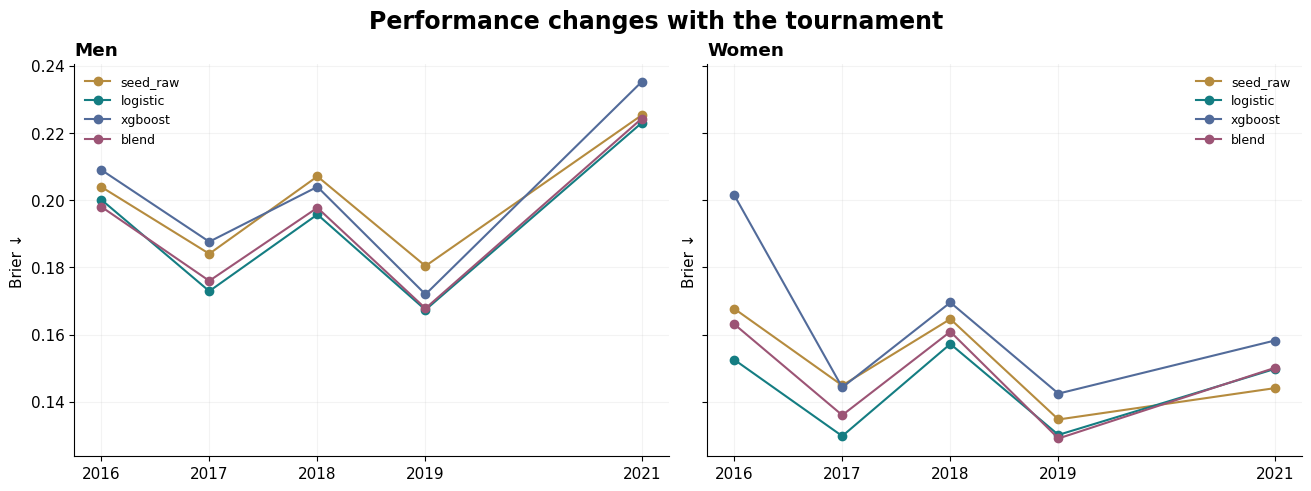

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, constrained_layout=True)
colors = {"seed_raw": "#b58b3e", "logistic_calibrated": "#147d82", "xgboost_calibrated": "#526b9a", "blend": "#9c5475"}
for ax, gender, title in zip(axes, ["M", "W"], ["Men", "Women"]):
    for model, color in colors.items():
        panel = metrics.query("Gender == @gender and block == @gender and model == @model")
        ax.plot(panel.Season, panel.brier, marker="o", label=model.replace("_calibrated", ""), color=color)
    ax.set_xticks(CONFIG["validation_seasons"])
    ax.set_title(title, loc="left")
    ax.set_ylabel("Brier ↓")
    ax.grid(alpha=0.15)
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("Performance changes with the tournament", fontsize=17, fontweight="bold")
plt.show()

## 7. Calibration is measured, not assumed

A well-calibrated group of 70% predictions wins roughly 70% of the time. Bin counts matter: sparse bins can look extreme by chance. The diagonal is perfect calibration. Temperature scaling is retained only when it beats identity on earlier calibration validation years.

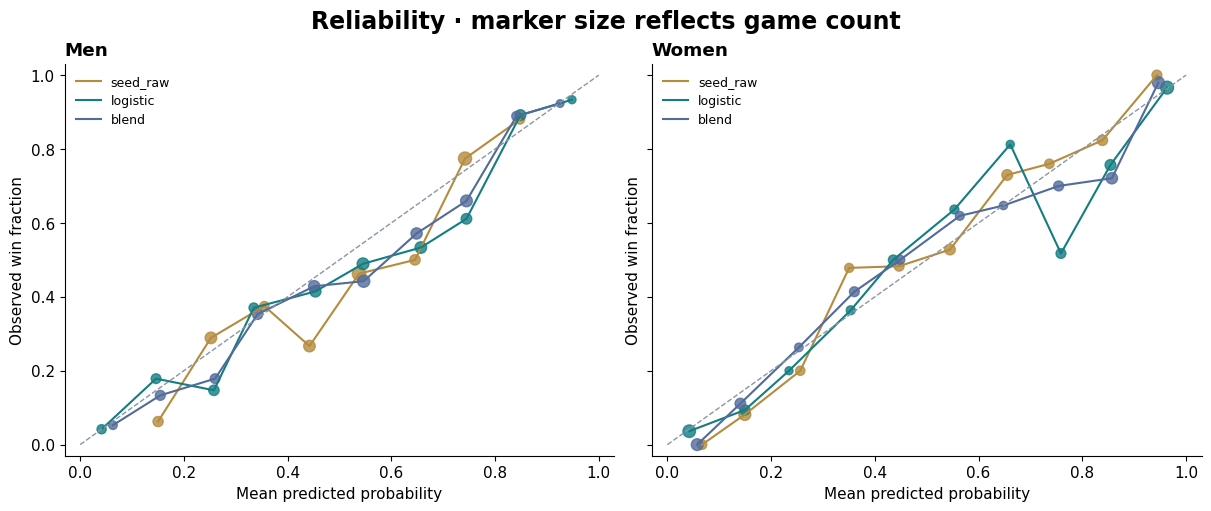

Gender,bin,predicted,observed,games
M,0,0.063328,0.052632,19
M,1,0.154579,0.133333,30
M,2,0.260272,0.178571,28
M,3,0.342210,0.352941,34
M,4,0.451355,0.428571,42
M,5,0.546707,0.442308,52
M,6,0.648690,0.571429,42
M,7,0.744830,0.659574,47
M,8,0.841346,0.888889,27
M,9,0.925408,0.923077,13


In [8]:
reliability = pd.read_csv(RESULTS / "reliability.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, gender, title in zip(axes, ["M", "W"], ["Men", "Women"]):
    for model, color in [("seed_raw", "#b58b3e"), ("logistic_calibrated", "#147d82"), ("blend", "#526b9a")]:
        panel = reliability.query("Gender == @gender and block == @gender and model == @model")
        ax.plot(panel.predicted, panel.observed, color=color, linewidth=1.5,
                label=model.replace("_calibrated", ""))
        ax.scatter(panel.predicted, panel.observed, s=15 + panel.games * 1.2, color=color, alpha=0.8)
    ax.plot([0, 1], [0, 1], linestyle="--", color="#8895a6", linewidth=1)
    ax.set(xlim=(-0.03, 1.03), ylim=(-0.03, 1.03), xlabel="Mean predicted probability", ylabel="Observed win fraction")
    ax.set_title(title, loc="left")
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("Reliability · marker size reflects game count", fontsize=17, fontweight="bold")
plt.show()
table(reliability.query("model == 'blend' and block != 'pooled_common'")
      [["Gender", "bin", "predicted", "observed", "games"]])

## 8. Paired uncertainty against a seed-only baseline

Each interval resamples whole seasons, pairing the same games for the candidate and baseline. Negative Brier differences favor the candidate. These exploratory intervals do not adjust for the many comparisons made, and should not be read as proof that a selected winner will generalize.

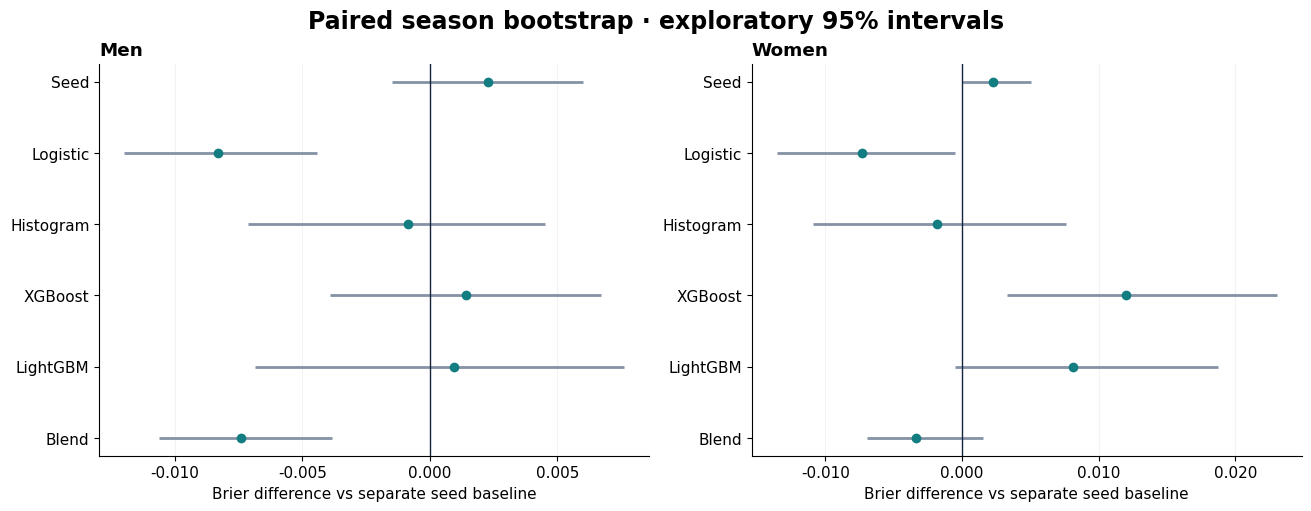

In [9]:
intervals = pd.read_csv(RESULTS / "paired_intervals.csv")
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, gender, title in zip(axes, ["M", "W"], ["Men", "Women"]):
    panel = intervals.query("Gender == @gender and block == @gender and model in @MODELS").set_index("model").loc[MODELS]
    y = np.arange(len(panel))
    ax.hlines(y, panel.ci_low, panel.ci_high, color="#8492a6", linewidth=2)
    ax.scatter(panel.brier_delta, y, color="#147d82", zorder=3)
    ax.axvline(0, color="#14243b", linewidth=1)
    ax.set_yticks(y, LABELS)
    ax.invert_yaxis()
    ax.set_title(title, loc="left")
    ax.set_xlabel("Brier difference vs separate seed baseline")
    ax.grid(axis="x", alpha=0.15)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
fig.suptitle("Paired season bootstrap · exploratory 95% intervals", fontsize=17, fontweight="bold")
plt.show()

## 9. What did the ensemble learn?

The weights below come only from earlier OOF games. They are constrained to sum to one and regularized toward equal weighting. The pooled models are trained jointly, but their settings and blend weights are selected separately for the men's and women's targets.

In [10]:
weights = pd.read_csv(RESULTS / "ensemble_weights.csv")
assert weights.weight.between(0, 1).all()
assert np.allclose(weights.groupby(["Gender", "route", "Season"]).weight.sum(), 1)
table(weights.query("Season == 2021").pivot(index=["Gender", "route"], columns="family", values="weight").reset_index())
LOG.emit("ensemble_contract_verified", contexts=len(weights.groupby(["Gender", "route", "Season"])))

family,Gender,route,hist,lightgbm,logistic,seed,xgboost
,M,M,0.044964,0.134411,0.545454,0.141686,0.133485
,M,pooled_common,0.125799,0.156903,0.405950,0.123667,0.187681
,W,W,0.193594,0.116557,0.445960,0.148737,0.095152
,W,pooled_common,0.157498,0.153242,0.480299,0.118717,0.090244


{"contexts": 20, "elapsed_seconds": 1.078, "event": "ensemble_contract_verified", "memory_status": "available", "rss_mb": 284.2, "timestamp": "2026-09-07T04:49:48.218253+00:00"}


## 10. Feature interpretation on held-out 2021 games

Permutation importance shuffles one feature and measures the increase in Brier while keeping the selected model fixed. Larger positive values indicate greater reliance on that feature in this fold. Correlated features can substitute for one another; shuffling can create unrealistic combinations. This is a diagnostic, not causal attribution or a rule for reselecting features on the same fold.

Five shuffles estimate permutation variability; they do not provide a statistical confidence interval across future tournaments.

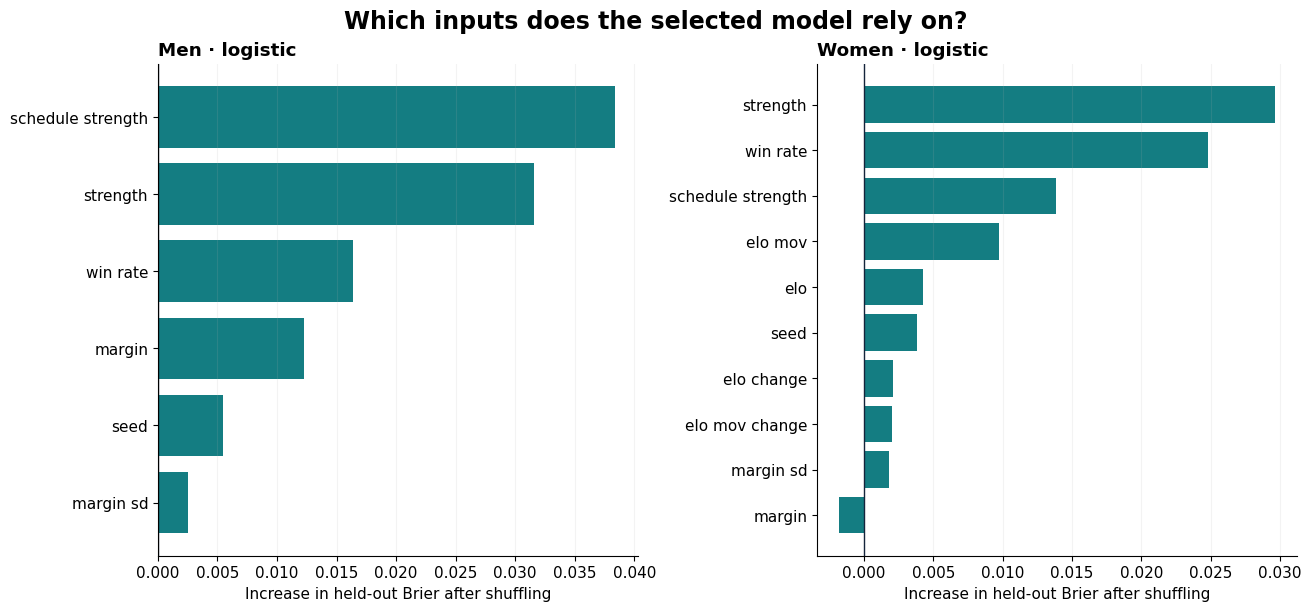

Gender,route,family,features_tested,repeats
M,M,hist,6,5
M,M,lightgbm,6,5
M,M,logistic,6,5
M,M,rank_logistic,19,5
M,M,xgboost,6,5
M,pooled_common,hist,101,5
M,pooled_common,lightgbm,101,5
M,pooled_common,logistic,6,5
M,pooled_common,xgboost,101,5
W,W,hist,6,5


In [11]:
importance = pd.read_csv(RESULTS / "permutation.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
for ax, gender, title in zip(axes, ["M", "W"], ["Men · logistic", "Women · logistic"]):
    panel = importance.query("Gender == @gender and route == @gender and family == 'logistic'").nlargest(10, "brier_increase")
    labels = panel.feature.str.removeprefix("diff_").str.replace("_", " ")
    ax.barh(labels, panel.brier_increase, color="#147d82")
    ax.axvline(0, color="#14243b", linewidth=1)
    ax.invert_yaxis()
    ax.set_title(title, loc="left")
    ax.set_xlabel("Increase in held-out Brier after shuffling")
    ax.grid(axis="x", alpha=0.15)
fig.suptitle("Which inputs does the selected model rely on?", fontsize=17, fontweight="bold")
plt.show()
table(importance.groupby(["Gender", "route", "family"]).agg(features_tested=("feature", "nunique"), repeats=("repeats", "first")).reset_index())

## 11. Inspect the largest errors

Confident misses are useful basketball case studies. They do not by themselves justify changing a model: the evaluation set must not become an unacknowledged tuning target.

In [12]:
table(pd.read_csv(RESULTS / "largest_errors.csv").head(12)
      [["Gender", "Season", "ID", "block", "y", "p", "squared_error"]])
threshold_view = leaderboard.query("model == 'blend'")
table(threshold_view[["Gender", "block", "brier", "log_loss", "roc_auc", "average_precision",
                      "precision_at_05", "recall_at_05", "f1_at_05", "ece_10_bins"]])

Gender,Season,ID,block,y,p,squared_error
M,2018,2018_1420_1438,pooled_common,1,0.044062,0.913817
M,2018,2018_1420_1438,M,1,0.058137,0.887107
M,2016,2016_1277_1292,pooled_common,0,0.928902,0.862860
W,2016,2016_3268_3449,W,0,0.921480,0.849125
W,2016,2016_3268_3449,pooled_common,0,0.916282,0.839573
M,2016,2016_1277_1292,M,0,0.915737,0.838575
M,2021,2021_1326_1331,pooled_common,0,0.904726,0.818530
W,2018,2018_3124_3333,pooled_common,0,0.903406,0.816142
W,2019,2019_3235_3283,pooled_common,0,0.901697,0.813058
W,2018,2018_3138_3199,W,1,0.106809,0.797789


Gender,block,brier,log_loss,roc_auc,average_precision,precision_at_05,recall_at_05,f1_at_05,ece_10_bins
M,M,0.192674,0.562494,0.778716,0.759608,0.629834,0.740260,0.680597,0.055224
M,pooled_common,0.190840,0.557529,0.786580,0.768873,0.646739,0.772727,0.704142,0.064253
W,W,0.147811,0.446953,0.870717,0.867532,0.775000,0.789809,0.782334,0.053964
W,pooled_common,0.146494,0.443318,0.873095,0.872331,0.773006,0.802548,0.787500,0.056151


## 12. Earlier results and the remaining modeling work

The historical model comparison used a different feature schema and broader training history, including neural frameworks and margin regressors. Its reports remain in `reports/modeling/03_model_comparison/`; its implementation remains in Git history. Historical and current scores are not interchangeable.

This notebook completes the current four-family tabular comparison. It does **not** claim to have rerun PyTorch or TensorFlow. The next modeling phase should reconcile the older rich-feature result, evaluate any added neural/margin challengers under the same current contract, then freeze a submission recipe in notebook 04. The already-consumed benchmark must stay explicitly retrospective.

**No new Kaggle submission was made by this run.** Existing submission evidence remains available in the repository.

In [13]:
historical = pd.read_csv(ROOT / "reports/modeling/03_model_comparison/matched_season_model_comparison.csv")
display(Markdown(f"Historical comparison retained: **{len(historical)} rows**. "
                 "Use its original reports for schema-specific details; no exact paired claim is made here."))
LOG.emit("notebook_completed", total_seconds=round(time.monotonic() - STARTED, 3),
         verified_streams=len(leaderboard), physical_games=SUMMARY["physical_validation_games"])
display(Markdown("**Notebook 03 complete.** Saved outputs include metric verification, "
                 "temporal audits, calibration, ensemble checks and held-out interpretation."))

Historical comparison retained: **54 rows**. Use its original reports for schema-specific details; no exact paired claim is made here.

{"elapsed_seconds": 1.33, "event": "notebook_completed", "memory_status": "available", "physical_games": 649, "rss_mb": 288.4, "timestamp": "2026-09-07T04:49:48.470261+00:00", "total_seconds": 1.33, "verified_streams": 46}


**Notebook 03 complete.** Saved outputs include metric verification, temporal audits, calibration, ensemble checks and held-out interpretation.

## Reproduction and durable artifacts

The published notebook already contains its outputs. Reviewers can inspect it without running anything. Maintainers can reproduce the experiment with `march-models`, which verifies and reuses completed candidate fits. Supplying `--s3` replicates each completed task to private S3.

```bash
.venv/bin/march-models --s3 s3://sagemaker-march-mania-560403859723-us-west-2/model-comparison
.venv/bin/python scripts/notebook.py --execute --publish
```

UTC timestamped events include task start/completion, elapsed time, progress, and 15-second heartbeats during long tasks. Failed tasks do not receive a completion checkpoint. Checkpoints include output SHA-256 hashes, input/config/source fingerprints, and model artifacts. A matching successful fit is reused; a damaged fit is recomputed.

`reports/model_comparison/run.json` records exact source/input hashes, the private archive URI, and its checksum. The archive includes model artifacts, predictions, the feature matrix and exact Python sources. The standalone interactive report accompanies the archive and the compact CSV evidence is published with this notebook.

Technical references: [XGBoost parameters](https://xgboost.readthedocs.io/en/release_3.1.0/parameter.html), [LightGBM 4.6 parameters](https://lightgbm.readthedocs.io/en/v4.6.0/Parameters.html), [official competition](https://www.kaggle.com/competitions/march-machine-learning-mania-2026).